# X-ray spectra by epoch

Per-epoch spectrum comparison (not a binning study — see the superseded
`xray_grouping_comparison` notebook's replacement). Each panel shows the
background-subtracted, 0.3-8 keV spectrum for one of the 3 unique Chandra epochs
(31211+31996 and 29071+29072 are each combined into one spectrum — see
`CLAUDE_xray_SOP.md` Steps 3.5/3.5b), grouped at `group_counts(15)` — the grouping
used for fitting (with C-stat/wstat, decided 2026-09-01: grouping level and fit
statistic are independent choices here, since an exact Poisson likelihood isn't
biased by coarser grouping the way chi2 would be, so 15 cts/bin is purely a
resolution/plotting convenience, not a statistical-validity requirement). Panels are
ordered chronologically by phase post-explosion, left to right, with phase given in
days post-explosion.

Explosion epoch: MJD 58445.0 (Maeda et al. 2023a).

**Color: each epoch uses its position in the single project-wide viridis epoch list
in `CLAUDE_plotting.md`** (shared with the radio SEDs, not a separate X-ray mapping —
updated 2026-09-01 to interleave these 3 X-ray epochs into that list), rather than
one fixed color for all panels.

Grouped data comes from `data/Chandra/spectral_fitting/extract_grouping_qa.py`
(run under `ciao-4.17` for Sherpa), which writes
`data/Chandra/spectral_fitting/grouping_qa/<epoch>_group15.csv`. This notebook only
plots, under the standard `18ivc_clean` kernel.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.time import Time
import functions

functions.set_plot_style()

GROUPING_QA_DIR = "../data/Chandra/spectral_fitting/grouping_qa"
T_EXPLOSION_MJD = 58445.0  # Maeda et al. 2023a

# (CSV/epoch key, display label for title, path to the epoch's source PHA for DATE-OBS)
# 3 unique epochs: 31211+31996 (one interrupted visit) and 29071+29072 (two visits
# at the same ~5 yr phase, merged per CLAUDE_xray_SOP.md Step 3.5b) are each one
# combined spectrum.
EPOCH_FILES = [
    ("20306", "20306", "../data/Chandra/20306/repro/SN2018ivc_specextract.pi"),
    ("29071_29072", "29071+29072", "../data/Chandra/29071_29072_merged/SN2018ivc_merged_src.pi"),
    ("31211_31996", "31211+31996", "../data/Chandra/31211_31996_merged/SN2018ivc_merged_src.pi"),
]

# Position of each X-ray epoch in the single project-wide viridis epoch list
# (CLAUDE_plotting.md "Epoch -> viridis color (SEDs)", x = linspace(1,0,11),
# updated 2026-09-01 to interleave these 3 epochs with the radio ones). Hardcoded
# here (not recomputed locally) so this always matches the canonical table.
EPOCH_VIRIDIS_X = {
    "20306": 0.900,        # 12.7 d
    "29071_29072": 0.400,  # 1868.7 d
    "31211_31996": 0.100,  # 2550.3 d
}

def epoch_title(display_label, path):
    h = fits.open(path)[1].header
    date_obs = h["DATE-OBS"][:10]
    mjd = Time(h["DATE-OBS"], format="isot", scale="utc").mjd
    phase_days = mjd - T_EXPLOSION_MJD
    return f"{display_label} ({date_obs}, ~{phase_days:.0f} days post-explosion)", phase_days

panels = []
for epoch_key, display_label, path in EPOCH_FILES:
    title, phase_days = epoch_title(display_label, path)
    panels.append((phase_days, epoch_key, title))
panels.sort(key=lambda p: p[0])

cmap = mpl.colormaps["viridis"]
epoch_colors = {k: cmap(x) for k, x in EPOCH_VIRIDIS_X.items()}

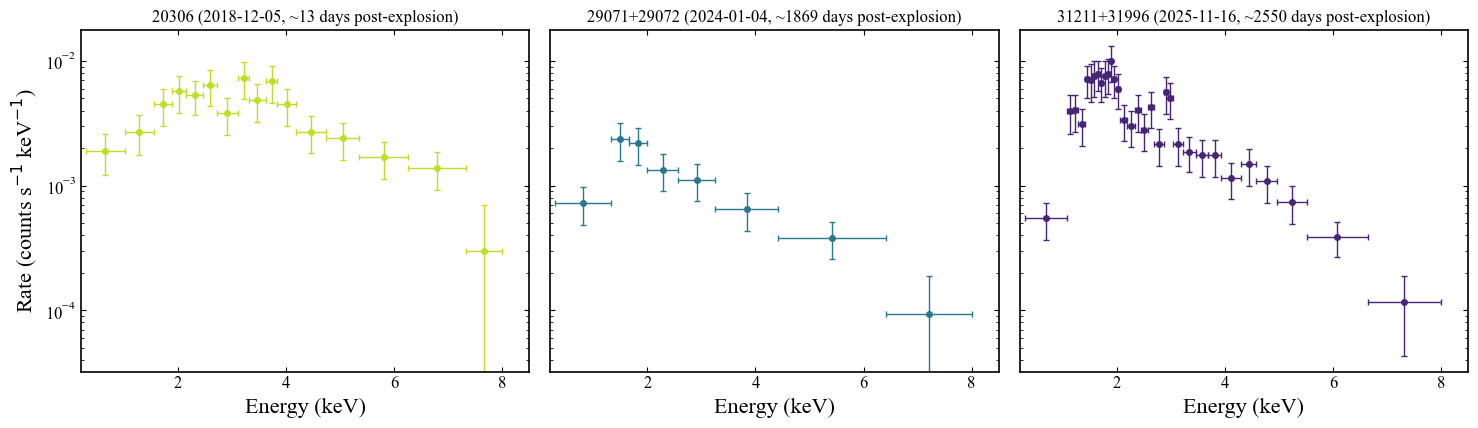

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)

for ax, (phase_days, epoch_key, title) in zip(axes, panels):
    df = pd.read_csv(f"{GROUPING_QA_DIR}/{epoch_key}_group15.csv")
    ax.errorbar(
        df["energy_kev"], df["rate"],
        xerr=df["energy_err_kev"], yerr=df["rate_err"],
        fmt="o", ms=4, capsize=2, lw=1.2, elinewidth=1,
        color=epoch_colors[epoch_key],
    )
    ax.set_title(title, fontsize=12)
    ax.set_yscale("log")
    ax.set_xlim(0.2, 8.5)
    ax.set_xlabel("Energy (keV)")

axes[0].set_ylabel(r"Rate (counts s$^{-1}$ keV$^{-1}$)")

fig.tight_layout()
fig.savefig("../figures/xray_spectra_by_epoch.png", dpi=200, bbox_inches="tight")
fig.savefig("../figures/xray_spectra_by_epoch.pdf", bbox_inches="tight")
plt.show()